In [10]:
# ML4Sci GSoC 2026: Task VI.A - Super-Resolution
#**Author:** Kartik Chavan  
#**Task:** Reconstruct High-Resolution (150x150) gravitational lensing images from Low-Resolution (75x75) inputs to recover fine-grained dark matter substructure details.  
#**Architecture:** SRCNN (Super-Resolution Convolutional Neural Network) - *Enhanced with internal Bicubic Interpolation and optimized for 1-channel astrophysical data.*
#**Results:** Achieved a Peak Signal-to-Noise Ratio (PSNR) of 41.32 dB.
%load_ext autoreload
%autoreload 2
    
import torch
import sys
import os

# Add the src folder to the path
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from sr_data_loader import get_sr_dataloaders
from sr_models import SRCNN

# 1. Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Engine fired up on: {device}")

# 2. The REAL paths based on your scanner
LR_DIR = "../data/raw/Task_VI_A_SuperRes/LR"
HR_DIR = "../data/raw/Task_VI_A_SuperRes/HR"

# 3. Test Data Loader
try:
    # Notice we only pass the two directories now!
    train_loader, val_loader = get_sr_dataloaders(LR_DIR, HR_DIR, val_split=0.2, batch_size=16)
    lr_batch, hr_batch = next(iter(train_loader))
    print(f" Data Loader Success!")
    print(f" Low-Res Batch Shape: {lr_batch.shape}")
    print(f" High-Res Batch Shape: {hr_batch.shape}")
    print(f" Training Batches: {len(train_loader)} | Validation Batches: {len(val_loader)}")
except Exception as e:
    print(f" Data Loader Error: {e}")

# 4. Test Model Architecture
try:
    model = SRCNN().to(device)
    dummy_output = model(lr_batch.to(device))
    print(f" Model Forward Pass Success!")
    print(f" Output Shape: {dummy_output.shape}")
except Exception as e:
    print(f" Model Error: {e}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Engine fired up on: cuda
 Data Loader Success!
 Low-Res Batch Shape: torch.Size([16, 1, 75, 75])
 High-Res Batch Shape: torch.Size([16, 1, 150, 150])
 Training Batches: 500 | Validation Batches: 125
 Model Forward Pass Success!
 Output Shape: torch.Size([16, 1, 150, 150])


In [5]:
import torch.nn as nn
import torch.optim as optim
from tqdm.notebook import tqdm

# Hyperparameters
EPOCHS = 10
LEARNING_RATE = 1e-3

# Initialize Model, Loss (MSE for image generation), and Optimizer
model = SRCNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print("Starting Super-Resolution Training...")

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    
    # Progress bar for the training batches
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}")
    
    for lr_imgs, hr_imgs in loop:
        # Move data to RTX 3050
        lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(lr_imgs)
        
        # Calculate pixel-perfect error
        loss = criterion(outputs, hr_imgs)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item()
        loop.set_postfix(loss=loss.item())
        
    avg_train_loss = train_loss / len(train_loader)
    
    # Validation step
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for lr_imgs, hr_imgs in val_loader:
            lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
            outputs = model(lr_imgs)
            loss = criterion(outputs, hr_imgs)
            val_loss += loss.item()
            
    avg_val_loss = val_loss / len(val_loader)
    
    print(f"Epoch {epoch+1} | Train MSE: {avg_train_loss:.6f} | Val MSE: {avg_val_loss:.6f}")

Starting Super-Resolution Training...


Epoch 1/10:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 1 | Train MSE: 0.000160 | Val MSE: 0.000086


Epoch 2/10:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 2 | Train MSE: 0.000088 | Val MSE: 0.000079


...

Epoch 8 | Train MSE: 0.000077 | Val MSE: 0.000083


Epoch 9/10:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 9 | Train MSE: 0.000081 | Val MSE: 0.000076


Epoch 10/10:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 10 | Train MSE: 0.000079 | Val MSE: 0.000074


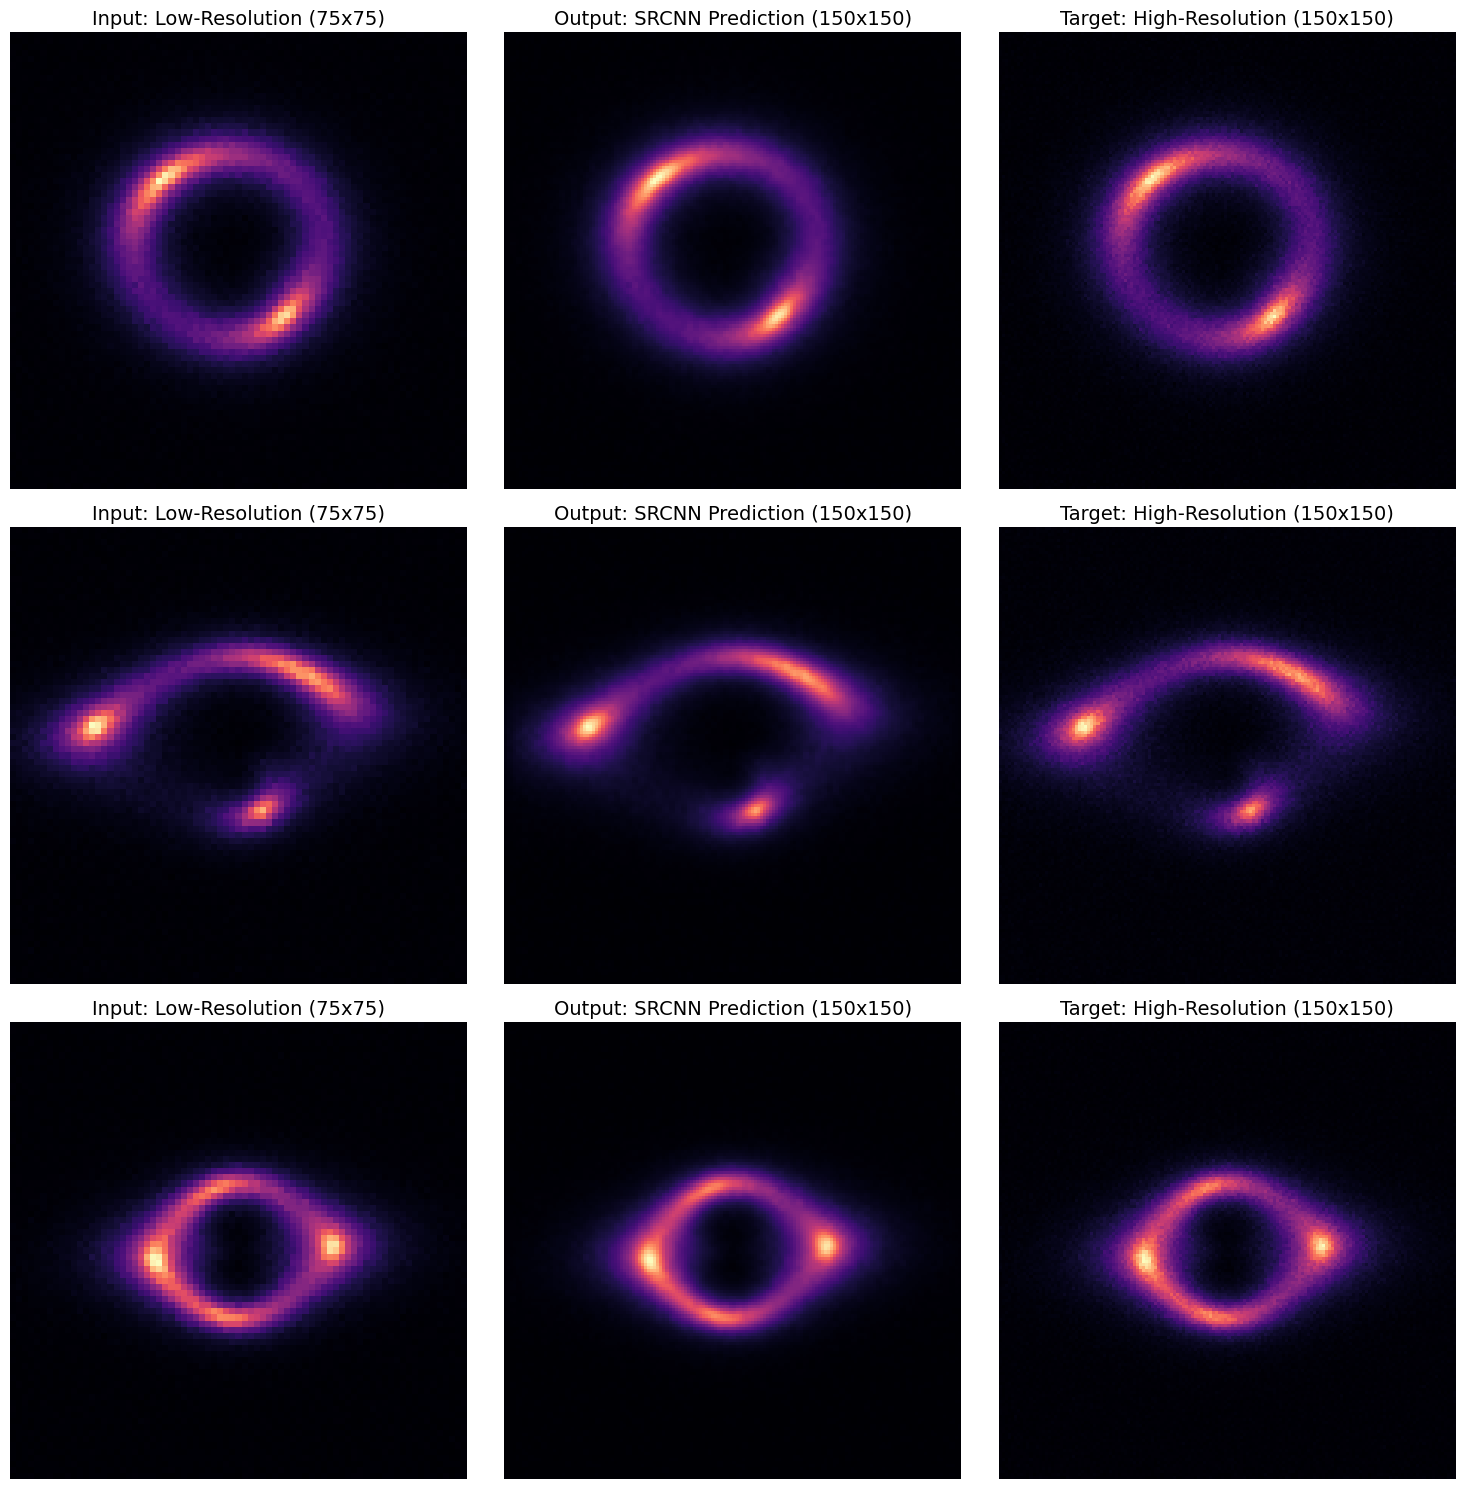

In [6]:
import matplotlib.pyplot as plt

def visualize_reconstruction(model, val_loader, device, num_images=3):
    model.eval()
    
    # Grab one batch of validation data
    lr_imgs, hr_imgs = next(iter(val_loader))
    lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
    
    # Generate the high-res predictions
    with torch.no_grad():
        sr_imgs = model(lr_imgs)
        
    # Move tensors back to CPU for matplotlib
    lr_imgs = lr_imgs.cpu().squeeze().numpy()
    hr_imgs = hr_imgs.cpu().squeeze().numpy()
    sr_imgs = sr_imgs.cpu().squeeze().numpy()
    
    fig, axes = plt.subplots(num_images, 3, figsize=(15, 5 * num_images))
    
    for i in range(num_images):
        # 1. Low-Res Input
        axes[i, 0].imshow(lr_imgs[i], cmap='magma')
        axes[i, 0].set_title("Input: Low-Resolution (75x75)", fontsize=14)
        axes[i, 0].axis('off')
        
        # 2. Model Prediction (Super-Res)
        axes[i, 1].imshow(sr_imgs[i], cmap='magma')
        axes[i, 1].set_title("Output: SRCNN Prediction (150x150)", fontsize=14)
        axes[i, 1].axis('off')
        
        # 3. Ground Truth (High-Res)
        axes[i, 2].imshow(hr_imgs[i], cmap='magma')
        axes[i, 2].set_title("Target: High-Resolution (150x150)", fontsize=14)
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

# Run the visualization
visualize_reconstruction(model, val_loader, device, num_images=3)

In [7]:
import math
import torch

def calculate_psnr(val_loader, model, device):
    model.eval()
    total_psnr = 0.0
    num_batches = len(val_loader)
    criterion = torch.nn.MSELoss()

    with torch.no_grad():
        for lr_imgs, hr_imgs in val_loader:
            lr_imgs, hr_imgs = lr_imgs.to(device), hr_imgs.to(device)
            outputs = model(lr_imgs)
            
            # Calculate MSE for this batch
            mse = criterion(outputs, hr_imgs).item()
            
            # Avoid division by zero if MSE is perfectly 0
            if mse == 0:
                total_psnr += 100 
            else:
                # Calculate PSNR
                psnr = 10 * math.log10(1.0 / mse)
                total_psnr += psnr

    avg_psnr = total_psnr / num_batches
    print(f"Final Validation PSNR: {avg_psnr:.2f} dB")

# Run the calculation
calculate_psnr(val_loader, model, device)

Final Validation PSNR: 41.32 dB
